# 2110573 PATTERN RECOGNITION

## **Homework 03:** GMM

- **Author:** Worralop Srichainont
- **Year:** 2025 (Semester 2)

# **Task**: Fisherface

- **Problem**: T5 - T25

# Dependencies

In [124]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage import img_as_float

# Data Resources

In [125]:
!wget -nc "https://drive.google.com/uc?id=18Vaza8W-IytHoZosPiYZP9dhyZcyWt7-" -O facedata_mat.zip
!unzip -o facedata_mat.zip

File ‘facedata_mat.zip’ already there; not retrieving.
Archive:  facedata_mat.zip
  inflating: facedata.mat            


In [126]:
FILE_PATH = "facedata.mat"

In [127]:
data = scipy.io.loadmat(FILE_PATH)
data_size = data["facedata"].shape

# Preprocessing xf

In [128]:
xf = np.zeros(
    (
        data_size[0],
        data_size[1],
        data["facedata"][0, 0].shape[0],
        data["facedata"][0, 0].shape[1],
    )
)
for i in range(data["facedata"].shape[0]):
    for j in range(data["facedata"].shape[1]):
        xf[i, j] = img_as_float(data["facedata"][i, j])

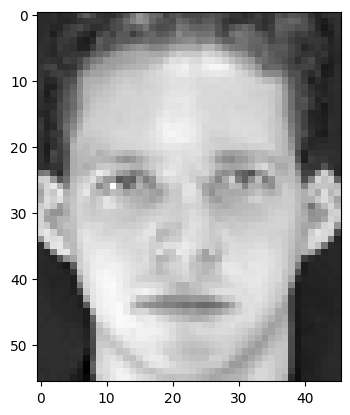

In [129]:
plt.imshow(xf[0, 0], cmap="gray")
plt.show()

# Problem `T5`

What is the Euclidean distance between xf[0,0] and xf[0,1]? What is the Euclidean distance between xf[0,0] and xf[1,0]? Does the numbers make sense? Do you think these numbers will be useful for face verification?

In [130]:
def L2_dist(x1, x2):
    """
    Calculate L2 distance.
    """
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [131]:
def test_L2_dist():
    assert L2_dist(np.array([1, 2, 3]), np.array([1, 2, 3])) == 0.0
    assert L2_dist(np.array([0, 0, 0]), np.array([1, 2, 3])) == np.sqrt(14)


test_L2_dist()

In [132]:
dist_same_person = L2_dist(xf[0, 0], xf[0, 1])
dist_diff_person = L2_dist(xf[0, 0], xf[1, 0])

print(f"Euclidean distance between xf[0, 0] and xf[0, 1] is {dist_same_person}")
print(f"Euclidean distance between xf[0, 0] and xf[1, 0] is {dist_diff_person}")

Euclidean distance between xf[0, 0] and xf[0, 1] is 10.037616294165492
Euclidean distance between xf[0, 0] and xf[1, 0] is 8.173295099737281


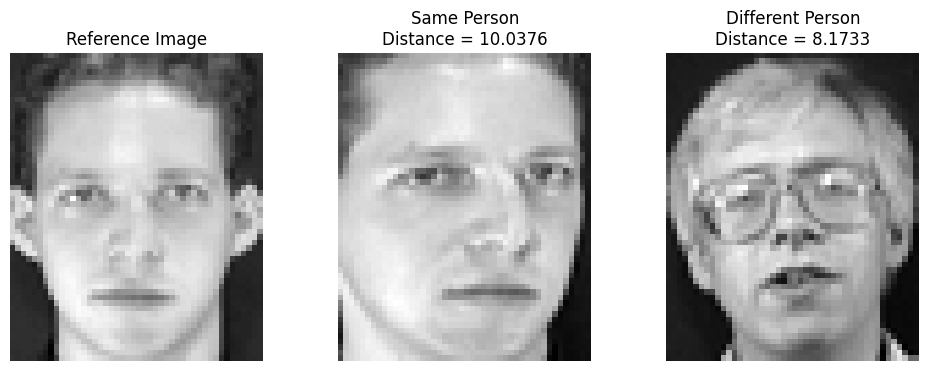

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Subplot for the first image
axes[0].imshow(xf[0, 0], cmap="gray")
axes[0].axis("off")
axes[0].set_title("Reference Image")

# Subplot for the second image
axes[1].imshow(xf[0, 1], cmap="gray")
axes[1].axis("off")
axes[1].set_title(f"Same Person\nDistance = {dist_same_person:.4f}")

# Subplot for the third image
axes[2].imshow(xf[1, 0], cmap="gray")
axes[2].axis("off")
axes[2].set_title(f"Different Person\nDistance = {dist_diff_person:.4f}")

# Plot images
plt.show()

## Answer

In terms of mathematical, it makes sense because different image should have distinct distance.

But in reality, sometimes it is nonsense, because different lighting and camera angle have more effect than the face structure itself.

# Problem `T6`

Write a function that takes in a set of feature vectors T and a set of feature vectors D, and then output the similarity matrix A. Show the matrix as an image.

Use the feature vectors from the first 3 images from all 40 people for list T (in order x[0, 0], x[0, 1], x[0, 2], x[1, 0], x[1, 1], ...x[39, 2]).

Use the feature vectors from the remaining 7 images from all 40 people for list D (in order x[0, 3], x[0, 4], x[0, 5], x[1, 6], x[0, 7], x[0, 8], x[0, 9], x[1, 3], x[1, 4]...x[39, 9]).

We will treat T as our training images and D as our testing images

In [134]:
def organize_shape(matrix):
    """
    Reduce matrix dimension of 2D image to 1D and merge people and image dimension.
    This function can be useful at organizing matrix shapes.

    Example:
        Input shape: (people_index, image_index, image_shape[0], image_shape[1])
        Output shape: (people_index*image_index, image_shape[0]*image_shape[1])
    """
    n_people, n_images, height, width = matrix.shape

    n_rows = n_people * n_images
    n_cols = height * width

    return matrix.reshape(n_rows, n_cols)

In [135]:
def generate_similarity_matrix(A, B):
    """
    Calculate similarity matrix M,
    which M[i, j] is a distance between A[i] and B[j].
    """
    diff = A[:, np.newaxis, :] - B[np.newaxis, :, :]
    similarity_matrix = np.sqrt(np.sum(diff**2, axis=-1))

    return similarity_matrix

In [136]:
def test_generate_similarity_matrix():
    test_A = np.array([[1, 2], [3, 4]])
    test_B = np.array([[1, 2], [5, 6], [7, 8]])
    expected_matrix = np.sqrt(np.array([[0, 32, 72], [8, 8, 32]]))
    assert (generate_similarity_matrix(test_A, test_B) == expected_matrix).all()


test_generate_similarity_matrix()

## Show Similarity Matrix

Calculate similarity matrix between `T` and `D`.

In [137]:
T_raw = xf[:, 0:3]
D_raw = xf[:, 3:10]

T_vector = organize_shape(T_raw)
D_vector = organize_shape(D_raw)

similarity_matrix = generate_similarity_matrix(T_vector, D_vector)

Plot similarity matrix between `T` and `D`.

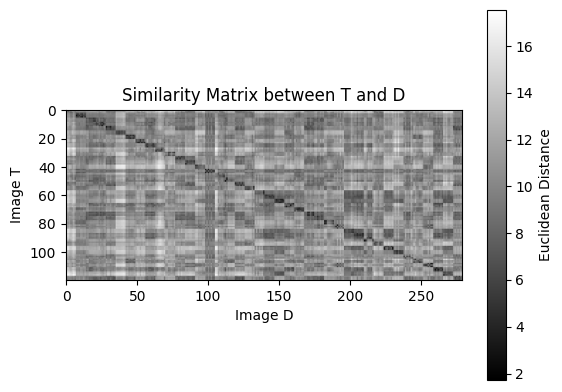

In [138]:
plt.figure()

plt.imshow(similarity_matrix, cmap="gray")
plt.colorbar(label="Euclidean Distance")

plt.title("Similarity Matrix between T and D")
plt.xlabel("Image D")
plt.ylabel("Image T")

plt.show()

# Problem `T7`

From the example similarity matrix above, what does the black square between [5:10,5:10] suggest about the pictures from person number 2? 

What do the patterns from person number 1 say about the images from person 1?

The black square from person number 2 in the similarity matrix means both images are similar.

Person number 1 has gray patterns, because it is not so similarity.

# Problem `T8`

Write a function that takes in the similarity matrix created from the previous part, and a threshold t as inputs.

The outputs of the function are the true positive rate and the false alarm rate of the face verification task (280 Test images, tested on 40 people, a total of 11200 testing per threshold).

What is the true positive rate and the false alarm rate for t = 10?

In [139]:
def evaluate_performance(similarity_matrix, threshold):
    """
    Calculate true positive rate and false alarm rate from given similarity_matrix and threshold.
    """
    n_test_images = similarity_matrix.shape[1]
    n_people = 40

    new_similarity_matrix = similarity_matrix.reshape(n_people, 3, n_test_images)

    min_dists = np.min(new_similarity_matrix, axis=1)

    pred = min_dists < threshold
    truth = np.zeros((n_people, n_test_images), dtype=bool)

    for idx in range(n_people):
        begin_col = 7 * idx
        end_col = 7 * (idx + 1)
        truth[idx, begin_col:end_col] = True

    positives = np.sum(truth)
    negatives = np.sum(~truth)
    true_positives = np.sum(pred & truth)
    false_positives = np.sum(pred & ~truth)

    true_pos_rate = true_positives / positives
    false_pos_rate = false_positives / negatives

    return true_pos_rate, false_pos_rate


evaluate_performance(similarity_matrix, 9.5)

(np.float64(0.9928571428571429), np.float64(0.33507326007326005))

In [140]:
THRESHOLD = 10.0

true_pos_rate, false_pos_rate = evaluate_performance(similarity_matrix, THRESHOLD)

print(f"Threshold = {THRESHOLD}")
print(f"- True Positive Rate: {true_pos_rate:.4f}")
print(f"- False Positive Rate: {false_pos_rate:.4f}")

Threshold = 10.0
- True Positive Rate: 0.9964
- False Positive Rate: 0.4564


# Problem `T9`

Plot the RoC curve for this simple verification system.

What should be the minimum threshold to generate the RoC curve?

What should be the maximum threshold? Your RoC should be generated from at least 1000 threshold levels equally spaced between the minimum and the maximum. (You should write a function for this).

In [141]:
def calculate_roc(input_mat):
    """
    Calculate a list of true_pos_rate and a list of false_pos_rate from the given matrix.
    """
    min_threshold = np.min(input_mat)
    max_threshold = np.max(input_mat) + 0.1

    thresholds = np.linspace(min_threshold, max_threshold, 1000)

    tpr_list = []
    fpr_list = []

    for t in thresholds:
        tpr, fpr = evaluate_performance(input_mat, t)
        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return tpr_list, fpr_list

In [142]:
def plot_roc(input_mat):
    """
    Plot RoC Curve from a given matrix.
    """
    tpr_list, fpr_list = calculate_roc(input_mat)

    plt.figure()
    plt.plot(fpr_list, tpr_list)
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")

    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.grid(True)

    plt.show()

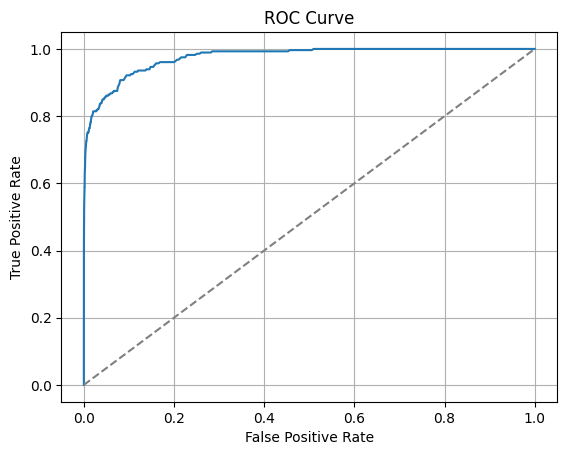

In [143]:
plot_roc(similarity_matrix)

## Answer

- **Minimum Threshold** should be 0 or the minimum value in the similarity threshold.
- **Maximum Threshold** should be maximum value in the similarity threshold.

# Problem `T10`

What is the EER (Equal Error Rate)?

What is the recall rate at 0.1% false alarm rate? (Write this in the same function as the previous question)

In [144]:
def calculate_metrics(tpr_list, fpr_list, thresholds):
    tpr = np.array(tpr_list)
    fpr = np.array(fpr_list)
    thresh = np.array(thresholds)

    eer_idx = np.argmin(np.abs(fpr - (1 - tpr)))

    eer = (fpr[eer_idx] + (1 - tpr[eer_idx])) / 2
    eer_thresh = thresh[eer_idx]

    TARGET_FPR = 0.001

    fpr_idx = np.argmin(np.abs(fpr - TARGET_FPR))
    recall = tpr[fpr_idx]

    return eer, 1 - eer, recall, eer_thresh

In [145]:
tpr, fpr = calculate_roc(similarity_matrix)
THRESHOLDS = np.linspace(0, 15, 1000)

eer, verification_rate, recall, eer_thresh = calculate_metrics(tpr, fpr, THRESHOLDS)

print(f"Equal Error Rate (EER): {eer:.4f}")
print(f"Verification Rate: {verification_rate:.4f}")
print(f"Recall at 0.1% FPR: {recall:.4f}")

Equal Error Rate (EER): 0.0896
Verification Rate: 0.9104
Recall at 0.1% FPR: 0.5464


# Problem `T11`

Compute the mean vector from the training images. Show the vector as an image (use numpy.reshape()).

This is typically called the meanface (or meanvoice for speech signals). You answer should look exactly like the image shown below.

In [146]:
T_raw = xf[:, 0:3]
n_people, n_images, height, width = T_raw.shape

X_train = T_raw.reshape(n_people * n_images, height, width)

mean_vector = np.mean(X_train, axis=0)
mean_face = mean_vector.reshape(height, width)

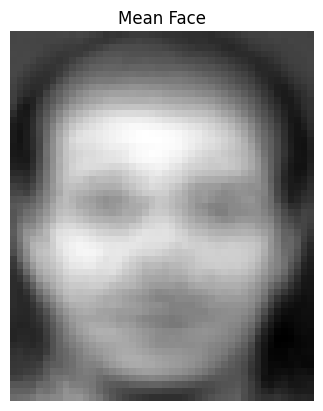

In [147]:
plt.imshow(mean_face, cmap="gray")
plt.title("Mean Face")
plt.axis("off")
plt.show()

# Problem `T12`

What is the size of the covariance matrix? What is the rank of the covariance matrix?

In [148]:
n_features = height * width
n_samples = 40 * 3

cov_matrix_size = (n_features, n_features)
cov_matrix_rank = min(n_samples - 1, n_features)

print(f"Covariance Matrix Size {cov_matrix_size}")
print(f"Covariance Matrix Rank {cov_matrix_rank}")

Covariance Matrix Size (2576, 2576)
Covariance Matrix Rank 119


# Problem `T13`

What is the size of the Gram matrix?

What is the rank of Gram matrix? If we compute the eigenvalues from the Gram matrix, how many non- zero eigenvalues do we expect to get?

In [149]:
X_train_flat = T_raw.reshape(120, -1)
X = X_train_flat.T

mean_vec_col = mean_vector.reshape(-1, 1)
X_hat = X - mean_vec_col

gram_matrix = np.dot(X_hat.T, X_hat)

In [150]:
gram_size = gram_matrix.shape
gram_rank = np.linalg.matrix_rank(gram_matrix)

print(f"Gram Matrix Size {gram_size}")
print(f"Gram Matrix Rank {gram_rank}")

Gram Matrix Size (120, 120)
Gram Matrix Rank 119


# Problem `T14`

Is the Gram matrix also symmetric? Why?

In [151]:
is_symmetric = np.allclose(gram_matrix, gram_matrix.T)
print(f"The Gram matrix is symmetric: {is_symmetric}")

The Gram matrix is symmetric: True


## Answer

The Gram matrix is symmetric, because each member is the dot product between two members which has the commutative property